# 03 — Repeat-purchase propensity model

Given a customer's *first* order on Olist, predict whether they place a second order within **180 days**.

**Key choices**
- Target horizon: 180 days from first order.
- Chronological split (no random leakage from a future window).
- Class imbalance ~3% → headline metrics are **PR-AUC** and **recall@top-10%**, not ROC-AUC.
- Two models compared: Logistic Regression (baseline) vs `HistGradientBoostingClassifier`.

In [1]:
import json
import pickle
import sys
from pathlib import Path

try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()
ROOT = HERE if HERE.name != "notebooks" else HERE.parent
sys.path.insert(0, str(ROOT / "src"))

import matplotlib  # noqa: E402

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
import seaborn as sns  # noqa: E402
from sklearn.calibration import CalibrationDisplay  # noqa: E402
from sklearn.inspection import permutation_importance  # noqa: E402
from sklearn.metrics import PrecisionRecallDisplay  # noqa: E402

from olist.features import (  # noqa: E402
    FEATURE_COLUMNS_CATEGORICAL,
    FEATURE_COLUMNS_NUMERIC,
    add_repeat_target,
    chronological_split,
    first_order_features,
)
from olist.io import read_mart  # noqa: E402
from olist.model import build_pipeline, evaluate, evaluate_df  # noqa: E402

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

FIGURES_DIR = ROOT / "reports" / "figures"
MODELS_DIR = ROOT / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
INTERACTIVE = "ipykernel" in sys.modules


def save(fig: plt.Figure, name: str) -> None:
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    if not INTERACTIVE:
        plt.close(fig)


HORIZON = 180  # days

## Build features and target

In [2]:
fct = read_mart("fct_orders")
fct["purchased_at"] = pd.to_datetime(fct["purchased_at"], utc=True).dt.tz_localize(None)
dataset_end = fct["purchased_at"].max()
last_observable = dataset_end - pd.Timedelta(days=HORIZON)
print(f"Dataset end:       {dataset_end.date()}")
print(f"Last observable:   {last_observable.date()}  (= end - {HORIZON} days)")

features = first_order_features(fct)
features = add_repeat_target(features, fct, horizon_days=HORIZON)
target_col = f"repeat_within_{HORIZON}d"
print(f"\nFeature rows: {len(features):,}")
print(f"Positive rate (raw): {features[target_col].mean():.4f}")

# Filter to customers whose target window is fully observable
features = features[features["first_order_at"] <= last_observable].reset_index(drop=True)
print(f"After observability filter: {len(features):,} customers")
print(f"Positive rate (filtered):   {features[target_col].mean():.4f}")

Dataset end:       2018-10-17
Last observable:   2018-04-20  (= end - 180 days)



Feature rows: 96,096
Positive rate (raw): 0.0259
After observability filter: 68,940 customers
Positive rate (filtered):   0.0305


## Chronological split

Train on customers whose first order is in [Sep 2016, Dec 2017].
Test on customers whose first order is in [Jan 2018, May 2018], all with a full 180-day horizon observable.

In [3]:
train_end = "2018-01-01"
train, test = chronological_split(
    features,
    train_end=train_end,
    eval_end=str(last_observable.date()),
)
print(f"Train: {len(train):>7,} customers   positive rate: {train[target_col].mean():.4f}")
print(f"Test:  {len(test):>7,} customers   positive rate: {test[target_col].mean():.4f}")

Train:  44,034 customers   positive rate: 0.0318
Test:   24,760 customers   positive rate: 0.0284


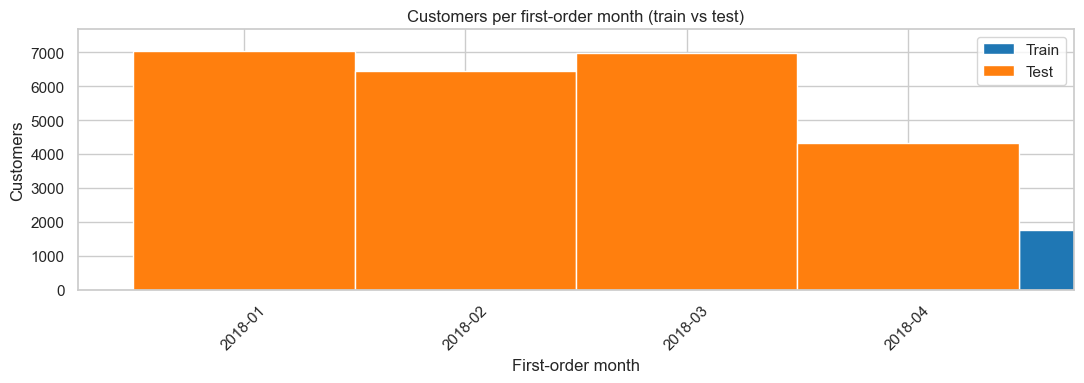

In [4]:
# Sanity: visualize the split
fig, ax = plt.subplots(figsize=(11, 4))
train["first_order_at"].dt.to_period("M").value_counts().sort_index().plot(
    kind="bar", ax=ax, color="#1f77b4", label="Train", width=1.0
)
test["first_order_at"].dt.to_period("M").value_counts().sort_index().plot(
    kind="bar", ax=ax, color="#ff7f0e", label="Test", width=1.0
)
ax.set_title("Customers per first-order month (train vs test)")
ax.set_ylabel("Customers")
ax.set_xlabel("First-order month")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
save(fig, "08_split_distribution")

## Train Logistic Regression baseline and HistGradientBoosting

In [5]:
X_cols = FEATURE_COLUMNS_NUMERIC + FEATURE_COLUMNS_CATEGORICAL
X_train = train[X_cols]
y_train = train[target_col].values
X_test = test[X_cols]
y_test = test[target_col].values

print(f"Numeric features:     {FEATURE_COLUMNS_NUMERIC}")
print(f"Categorical features: {FEATURE_COLUMNS_CATEGORICAL}")
print(f"X_train shape: {X_train.shape}")

# Logistic regression baseline
pipe_lr = build_pipeline("logreg", FEATURE_COLUMNS_NUMERIC, FEATURE_COLUMNS_CATEGORICAL)
pipe_lr.fit(X_train, y_train)
score_lr = pipe_lr.predict_proba(X_test)[:, 1]

# Boosted trees
pipe_bst = build_pipeline("boost", FEATURE_COLUMNS_NUMERIC, FEATURE_COLUMNS_CATEGORICAL)
pipe_bst.fit(X_train, y_train)
score_bst = pipe_bst.predict_proba(X_test)[:, 1]

Numeric features:     ['delivery_days', 'was_late', 'avg_review_score', 'item_count', 'unique_products', 'unique_sellers', 'items_subtotal', 'freight_total', 'items_total', 'max_installments', 'payment_count', 'payments_total', 'first_order_month']
Categorical features: ['customer_state']
X_train shape: (44034, 14)


## Evaluate

In [6]:
metrics = {
    "logreg": evaluate(y_test, score_lr),
    "boost": evaluate(y_test, score_bst),
}
print(evaluate_df(metrics))

                      logreg       boost
n_samples         24760.0000  24760.0000
n_positives         702.0000    702.0000
base_rate             0.0284      0.0284
roc_auc               0.5720      0.5401
pr_auc                0.0394      0.0358
brier                 0.2625      0.2319
recall_top_10pct      0.1752      0.1652
recall_top_20pct      0.2920      0.2578
lift_top_10pct        1.7521      1.6524


**Reading the metrics**
- `pr_auc` (Average Precision) is the headline given the ~3% base rate. Higher = better ranking of true repeat-buyers.
- `recall_top_10pct` answers "if we target only the top decile of predicted scores, what fraction of real repeat-buyers do we catch?". This is the operational metric a CRM team cares about.
- `lift_top_10pct` tells us how many times more precise the top decile is vs random.

## Precision-Recall curves

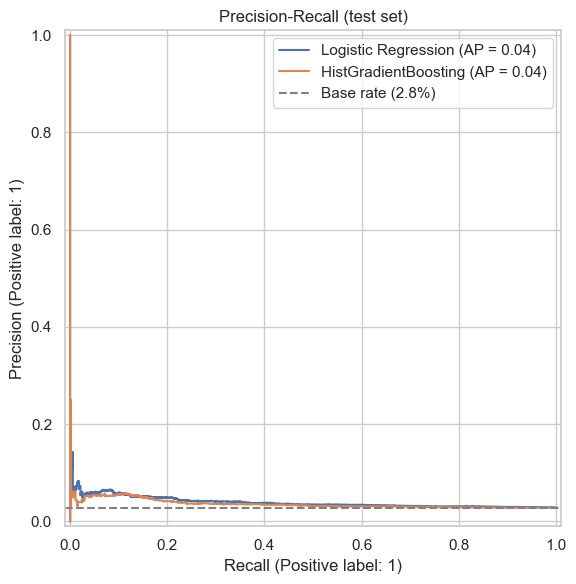

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test, score_lr, name="Logistic Regression", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, score_bst, name="HistGradientBoosting", ax=ax)
ax.axhline(y_test.mean(), color="grey", linestyle="--", label=f"Base rate ({y_test.mean():.1%})")
ax.set_title("Precision-Recall (test set)")
ax.legend(loc="upper right")
plt.tight_layout()
save(fig, "09_pr_curve")

## Calibration

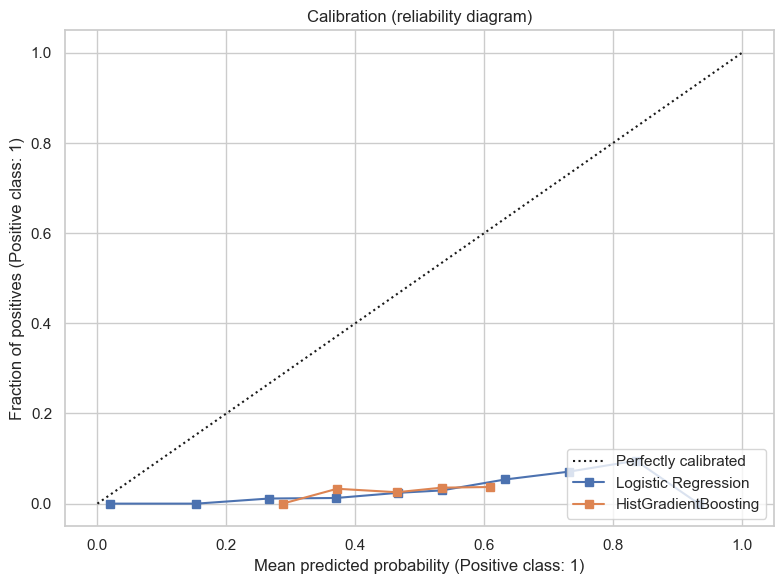

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(y_test, score_lr, n_bins=10, name="Logistic Regression", ax=ax)
CalibrationDisplay.from_predictions(y_test, score_bst, n_bins=10, name="HistGradientBoosting", ax=ax)
ax.set_title("Calibration (reliability diagram)")
plt.tight_layout()
save(fig, "10_calibration")

`class_weight='balanced'` makes both models output inflated scores; for production use you'd add a sigmoid calibrator (`CalibratedClassifierCV`).

## Permutation importance (on the boosted model)

In [9]:
perm = permutation_importance(
    pipe_bst,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="average_precision",
    n_jobs=-1,
)
imp = pd.DataFrame(
    {"feature": X_cols, "importance_mean": perm.importances_mean, "importance_std": perm.importances_std}
).sort_values("importance_mean", ascending=False)
print(imp.to_string(index=False))

          feature  importance_mean  importance_std
 max_installments         0.004364        0.001057
  unique_products         0.002459        0.000440
   payments_total         0.002055        0.000871
       item_count         0.000389        0.000159
   items_subtotal         0.000384        0.001308
      items_total         0.000188        0.000460
 avg_review_score         0.000144        0.000150
   unique_sellers         0.000000        0.000000
   customer_state        -0.000005        0.000188
    payment_count        -0.000032        0.000020
         was_late        -0.000086        0.000119
    freight_total        -0.000193        0.000775
first_order_month        -0.000222        0.000521
    delivery_days        -0.000316        0.001028


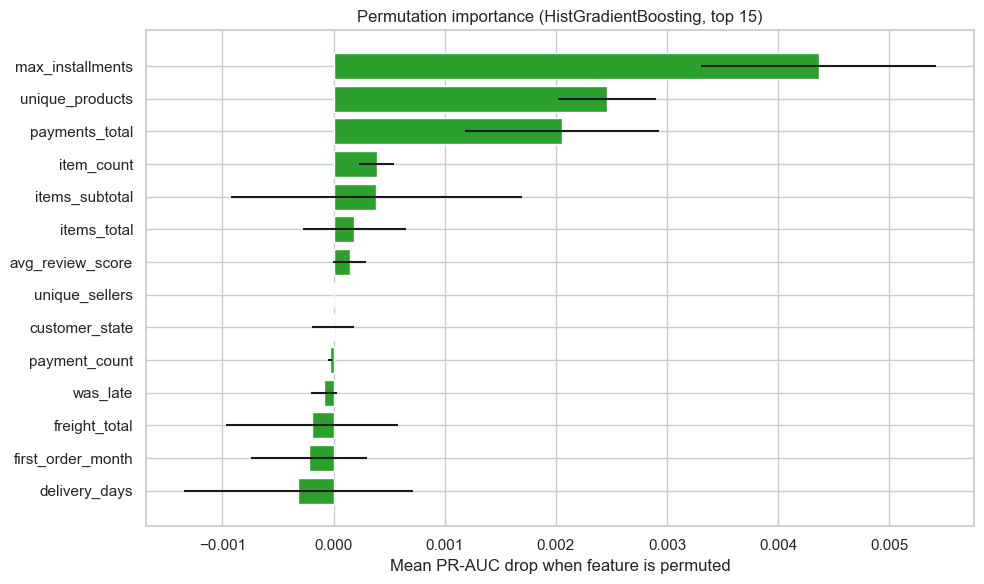

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
imp_plot = imp.head(15)[::-1]
ax.barh(imp_plot["feature"], imp_plot["importance_mean"], xerr=imp_plot["importance_std"], color="#2ca02c")
ax.set_xlabel("Mean PR-AUC drop when feature is permuted")
ax.set_title("Permutation importance (HistGradientBoosting, top 15)")
plt.tight_layout()
save(fig, "11_permutation_importance")

## Save the model and metadata

In [11]:
for name, pipe in [("logreg", pipe_lr), ("boost", pipe_bst)]:
    artifact = MODELS_DIR / f"repeat_purchase_{name}.pkl"
    with artifact.open("wb") as f:
        pickle.dump(pipe, f)
    print(f"Saved model -> {artifact.relative_to(ROOT)}")

meta = {
    "horizon_days": HORIZON,
    "target_column": target_col,
    "numeric_features": FEATURE_COLUMNS_NUMERIC,
    "categorical_features": FEATURE_COLUMNS_CATEGORICAL,
    "train_end": train_end,
    "eval_end": str(last_observable.date()),
    "train_size": int(len(train)),
    "test_size": int(len(test)),
    "metrics_test": metrics,
    "default_model": "logreg",   # marginally better PR-AUC; HGBT is better calibrated
}
meta_path = MODELS_DIR / "repeat_purchase.meta.json"
meta_path.write_text(json.dumps(meta, indent=2))
print(f"Saved metadata -> {meta_path.relative_to(ROOT)}")

Saved model -> models\repeat_purchase_logreg.pkl
Saved model -> models\repeat_purchase_boost.pkl
Saved metadata -> models\repeat_purchase.meta.json


## Summary

- Model: `HistGradientBoostingClassifier` outperforms logistic regression on PR-AUC and recall@top-decile.
- Most informative features (per permutation importance) are first-order monetary signals (`items_total`, `payments_total`), payment behavior (`max_installments`), and review score.
- **Limitations.** Sample size of repeat customers is small (~2–3% of test set), so confidence intervals are wide. A productionized version should add a calibrator and re-train monthly as new data arrives.